Saving Mall_Customers.csv to Mall_Customers.csv
First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)


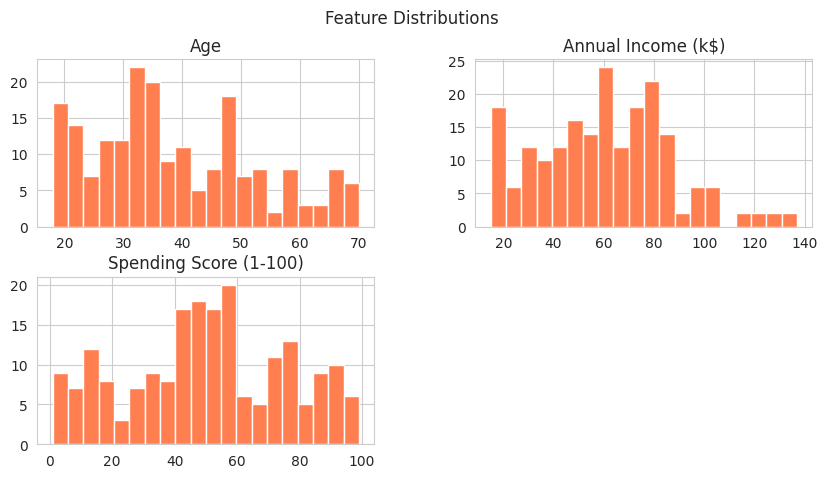

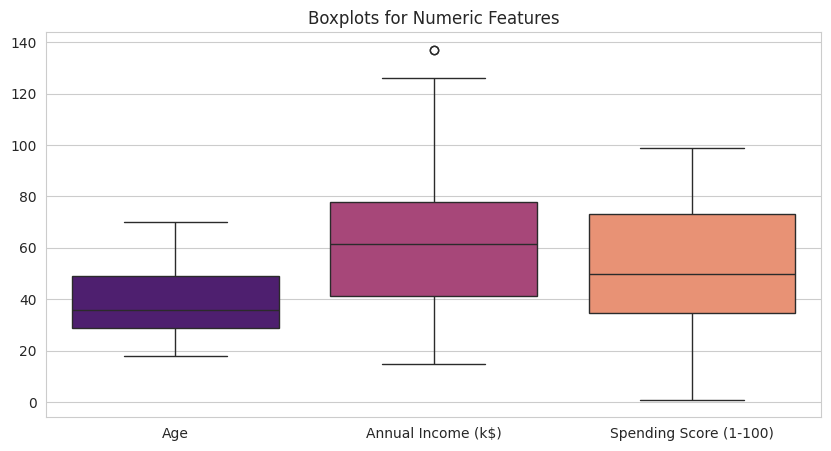

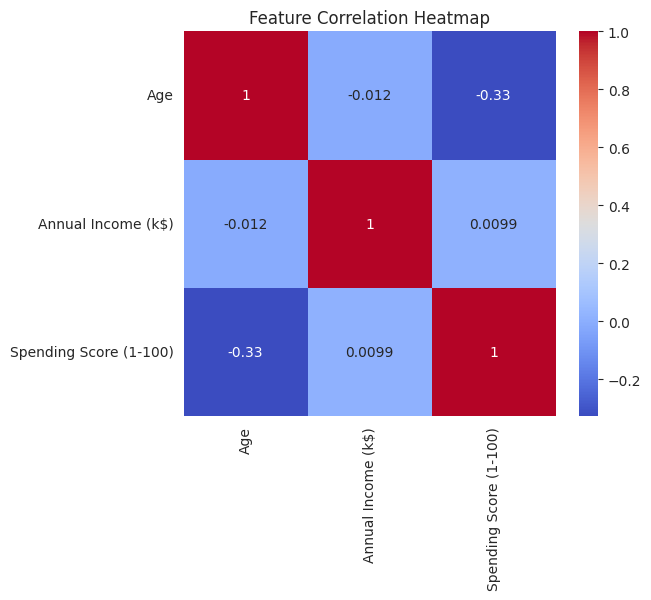

Removed 0 outliers


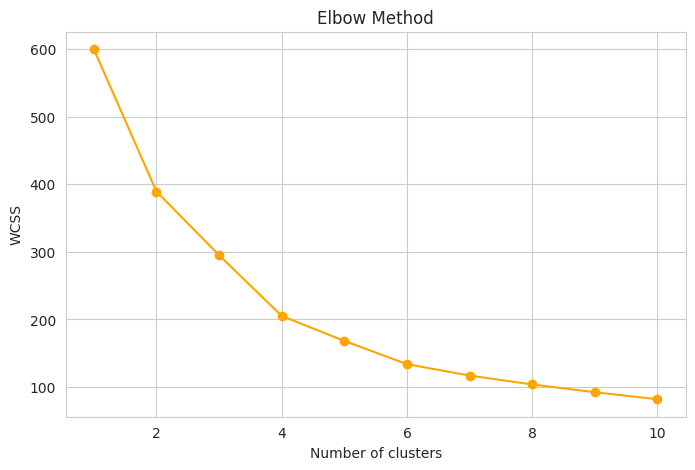

Silhouette Score: 0.417


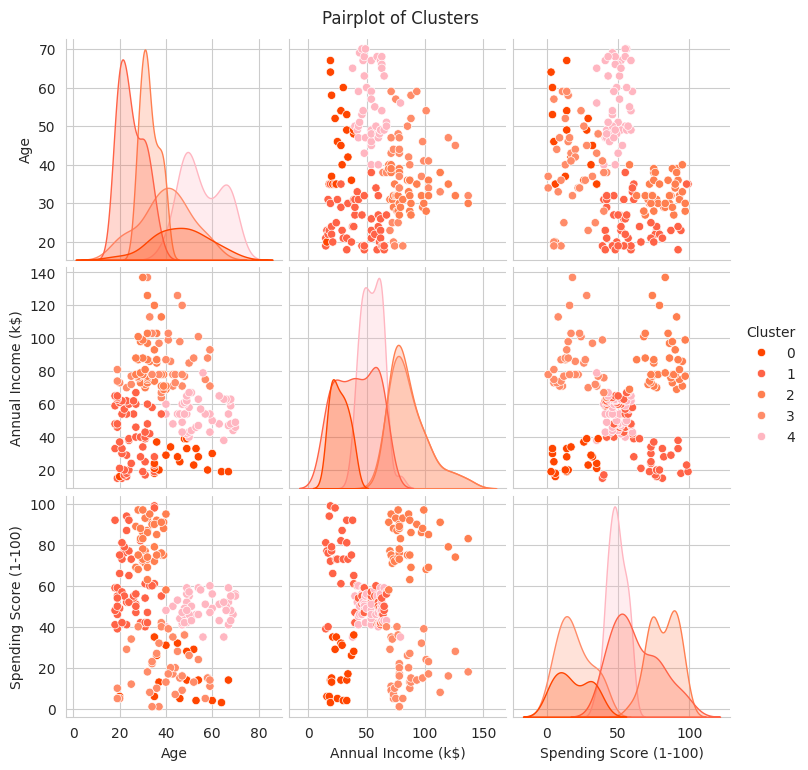

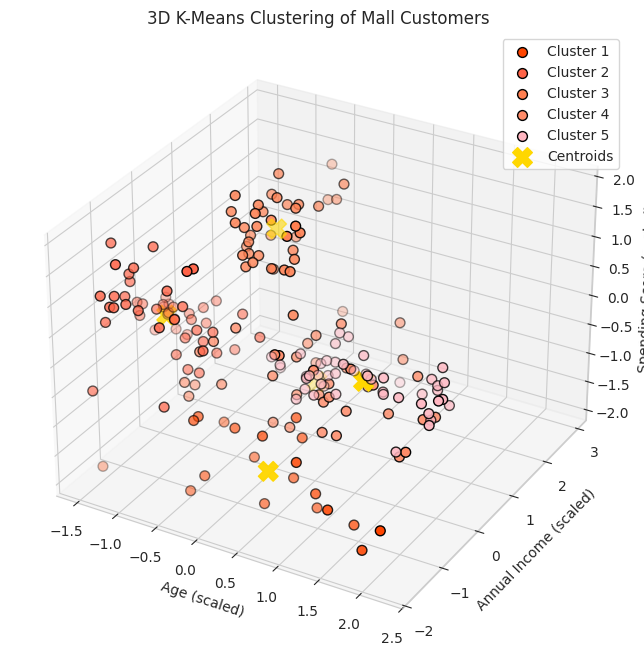


Cluster Centers (scaled features):
        Age  Annual Income  Spending Score
0  0.531074      -1.290508       -1.236467
1 -0.980679      -0.743060        0.467440
2 -0.428806       0.974847        1.216085
3  0.073331       0.974945       -1.197297
4  1.204841      -0.235773       -0.052368

Cluster Means (original scale):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064

Cluster Sizes:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


In [1]:
# --- Mall Customers K-Means Clustering ---

# =============================
# 1️⃣ Import libraries
# =============================
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

# =============================
# 2️⃣ Environment setup
# =============================
RANDOM_STATE = 42
N_INIT = 20

os.makedirs("figures", exist_ok=True)
sns.set_style("whitegrid")

# =============================
# 3️⃣ Load dataset
# =============================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:\n", df.head())
print("\nDataset info:")
df.info()

# =============================
# 4️⃣ Exploratory Data Analysis
# =============================

# Histograms (COLOR UNCHANGED)
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(
    figsize=(10, 5),
    bins=20,
    color='#FF7F50'
)
plt.suptitle("Feature Distributions")
plt.savefig("figures/histograms.png", dpi=300, bbox_inches="tight")
plt.show()

# Boxplots (COLOR UNCHANGED)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
    palette='magma'
)
plt.title("Boxplots for Numeric Features")
plt.savefig("figures/boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation heatmap (COLOR UNCHANGED)
plt.figure(figsize=(6, 5))
sns.heatmap(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 5️⃣ Outlier detection (Z-score)
# =============================
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_numeric = df[features]

z_scores = np.abs(zscore(X_numeric))
mask = (z_scores < 3).all(axis=1)

df_clean = df.loc[mask].reset_index(drop=True)
X_clean = X_numeric.loc[mask].reset_index(drop=True)

print(f"Removed {len(df) - len(df_clean)} outliers")

# =============================
# 6️⃣ Feature scaling
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# =============================
# 7️⃣ Elbow Method
# =============================
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=N_INIT,
        random_state=RANDOM_STATE
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='orange')  # COLOR UNCHANGED
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.savefig("figures/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 8️⃣ K-Means Clustering (k = 5)
# =============================
k = 5

kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    n_init=N_INIT,
    random_state=RANDOM_STATE
)

clusters = kmeans.fit_predict(X_scaled)
df_clean['Cluster'] = clusters

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(sil_score, 3))

# =============================
# 9️⃣ Pairplot (COLORS UNCHANGED)
# =============================
palette_colors = ['#FF4500', '#FF6347', '#FF7F50', '#FF8C69', '#FFB6C1']

pairplot = sns.pairplot(
    df_clean,
    vars=features,
    hue='Cluster',
    palette=palette_colors
)
pairplot.fig.suptitle("Pairplot of Clusters", y=1.02)
pairplot.fig.savefig("figures/cluster_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 🔟 3D Visualization (COLORS UNCHANGED)
# =============================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    ax.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        X_scaled[clusters == i, 2],
        s=50,
        c=palette_colors[i],
        label=f'Cluster {i+1}',
        edgecolor='k'
    )

# Centroids
ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=200,
    c='gold',
    marker='X',
    label='Centroids'
)

ax.set_title("3D K-Means Clustering of Mall Customers")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Annual Income (scaled)")
ax.set_zlabel("Spending Score (scaled)")
ax.legend()

plt.savefig("figures/3d_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 1️⃣1️⃣ Cluster Profiling
# =============================
print("\nCluster Centers (scaled features):")
print(pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Age', 'Annual Income', 'Spending Score']
))

print("\nCluster Means (original scale):")
print(
    df_clean.groupby('Cluster')[features].mean()
)

print("\nCluster Sizes:")
print(df_clean['Cluster'].value_counts().sort_index())
